# CHAPTER 3 深度神经网络

在第二章中，我们介绍了浅层神经网络的前向传播过程，并引入了**折叠空间**的核心直觉：激活函数 ReLU 赋予神经网络"弯曲"和"折叠"空间的能力，而神经元数量决定了能折叠多少次。

这一章我们将沿着"折叠"这条线索继续深入。第二章的策略是**横向扩展**——在同一层中增加神经元数量。本章我们探讨另一种策略：**纵向扩展**——堆叠多个隐藏层，构建**深度神经网络**。

> 本章的核心参考是 *Understanding Deep Learning*（UDL）第 4 章。

## 3.1 从宽度到深度：为什么要堆叠层？

回顾第二章，单隐层 ReLU 网络可以理解为：用 $D$ 个隐藏神经元，在输入空间上制造 $D$ 个"折痕"，形成最多 $D+1$ 个线性区域。

但这种方式有一个隐含的低效之处：**每个折痕只能作用于原始输入空间**。如果我们先对输入做一次变换，再在这个**变换后的空间**上施加折痕呢？

这就是深度网络的核心思想：**通过堆叠多个隐藏层，让每一次"折叠"都建立在前一次折叠的结果之上**。

为了建立直觉，我们先考虑一个最简单的深度构造：把**两个**浅层网络首尾相连——第一个网络的输出直接作为第二个网络的输入。

## 3.2 组合两个浅层网络

考虑以下构造（对应 UDL 图 4.1）。两个网络各有 3 个 ReLU 隐藏单元，各自产生 3 段交替斜率的线性区域。

<img src="../attachment/图3-1.jpg" width="700" style="display: block; margin: 0 auto;" >

**第一个网络** $f_1: x \rightarrow y$：

$$
\begin{aligned}
h_1 &= \text{ReLU}[\theta_{10} + \theta_{11} x] \\
h_2 &= \text{ReLU}[\theta_{20} + \theta_{21} x] \\
h_3 &= \text{ReLU}[\theta_{30} + \theta_{31} x] \\
y   &= \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3
\end{aligned}
$$

**第二个网络** $f_2: y \rightarrow y'$：

$$
\begin{aligned}
h'_1 &= \text{ReLU}[\theta'_{10} + \theta'_{11} y] \\
h'_2 &= \text{ReLU}[\theta'_{20} + \theta'_{21} y] \\
h'_3 &= \text{ReLU}[\theta'_{30} + \theta'_{31} y] \\
y'   &= \phi'_0 + \phi'_1 h'_1 + \phi'_2 h'_2 + \phi'_3 h'_3
\end{aligned}
$$


整体映射为 $y' = f_2(f_1(x))$。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def relu(z):
    return np.maximum(0, z)

class ShallowNet1:
    def __init__(self):
        self.theta_0 = np.array([1.0, 1/3, -1/3])
        self.theta_1 = np.array([1.0, 1.0,  1.0])
        self.phi_0   = -1.0
        self.phi     = np.array([3.0, -6.0, 6.0])

    def forward(self, x):
        h1 = relu(self.theta_0[0] + self.theta_1[0] * x)
        h2 = relu(self.theta_0[1] + self.theta_1[1] * x)
        h3 = relu(self.theta_0[2] + self.theta_1[2] * x)
        y  = self.phi_0 + self.phi[0]*h1 + self.phi[1]*h2 + self.phi[2]*h3
        return y, (h1, h2, h3)

net1 = ShallowNet1()

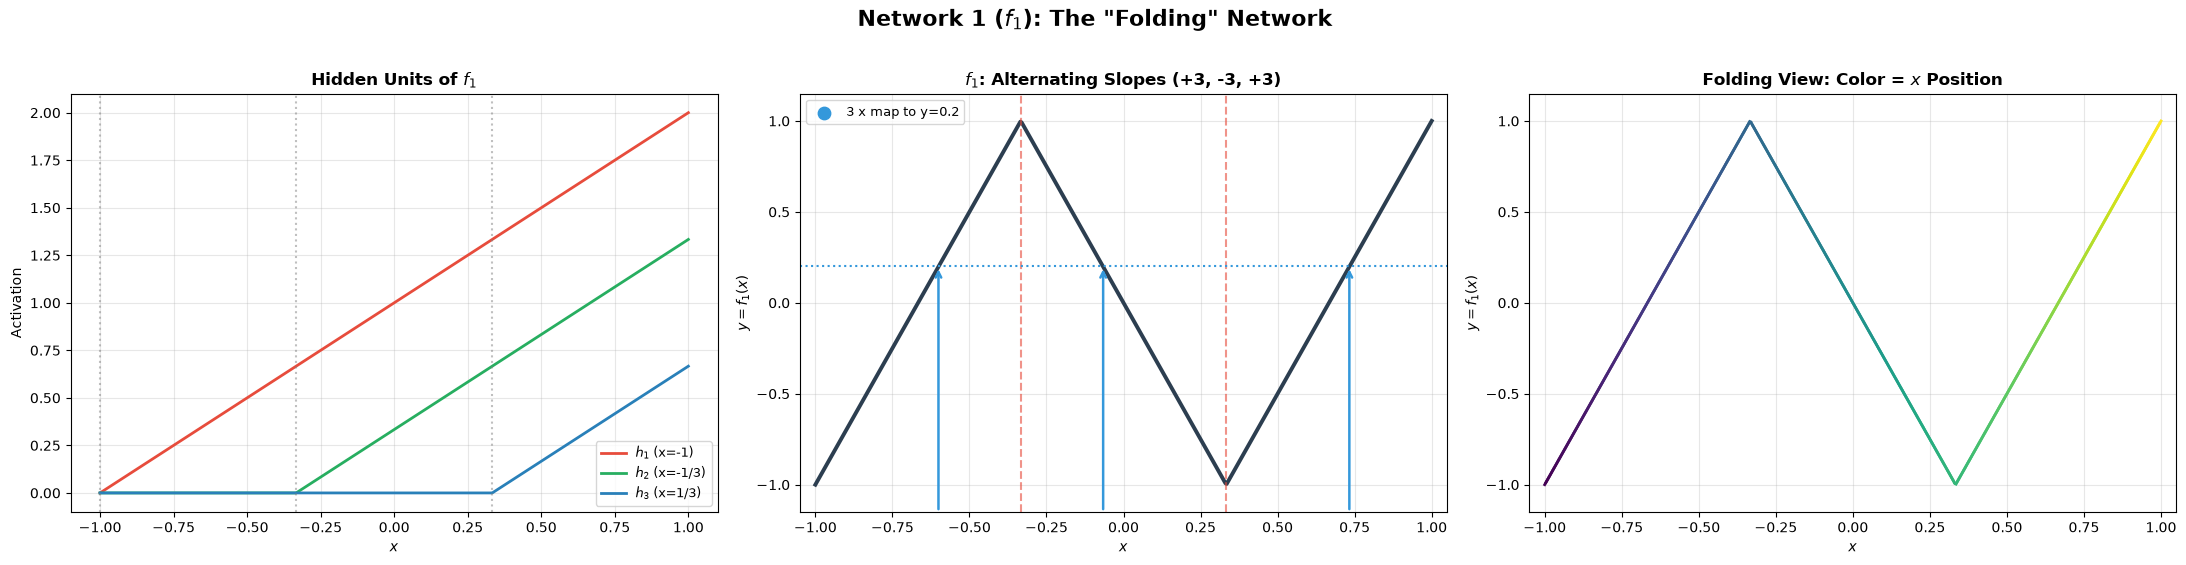

In [3]:
# 可视化第一个网络
x_dense = np.linspace(-1, 1, 500)
y_dense, hs_dense = net1.forward(x_dense)

fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))

# Panel A: 隐藏单元激活
ax = axes[0]
colors_h = ['#E74C3C', '#27AE60', '#2980B9']
for i in range(3):
    ax.plot(x_dense, hs_dense[i], color=colors_h[i], linewidth=2,
            label=[r'$h_1$ (x=-1)', r'$h_2$ (x=-1/3)', r'$h_3$ (x=1/3)'][i])
for jx in [-1, -1/3, 1/3]:
    ax.axvline(x=jx, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('$x$'); ax.set_ylabel('Activation')
ax.set_title('Hidden Units of $f_1$', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(-1.1, 1.1)

# Panel B: f1 输出函数
ax = axes[1]
ax.plot(x_dense, y_dense, '#2C3E50', linewidth=2.8)
for jx in [-1/3, 1/3]:
    ax.axvline(x=jx, color='#E74C3C', linestyle='--', alpha=0.6)

# 展示折叠: 3个不同的x映射到同一个y
y_demo = 0.2
for rx in [np.linspace(-1, -1/3, 500), np.linspace(-1/3, 1/3, 500), np.linspace(1/3, 1, 500)]:
    yr, _ = net1.forward(rx)
    xm = rx[np.argmin(np.abs(yr - y_demo))]
    ax.annotate('', xy=(xm, y_demo), xytext=(xm, -1.15),
                arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.8))
ax.axhline(y=y_demo, color='#3498DB', linestyle=':', linewidth=1.5)
ax.scatter([],[],c='#3498DB',s=80,label=f'3 x map to y={y_demo}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y = f_1(x)$')
ax.set_title('$f_1$: Alternating Slopes (+3, -3, +3)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15)

# Panel C: 折叠视角（颜色编码）
ax = axes[2]
xc = plt.cm.viridis((x_dense + 1) / 2)
for i in range(len(x_dense)-1):
    ax.plot(x_dense[i:i+2], y_dense[i:i+2], color=xc[i], linewidth=2)
ax.set_xlabel('$x$'); ax.set_ylabel('$y = f_1(x)$')
ax.set_title('Folding View: Color = $x$ Position', fontweight='bold')
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15); ax.grid(True, alpha=0.3)

fig.suptitle('Network 1 ($f_1$): The "Folding" Network', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

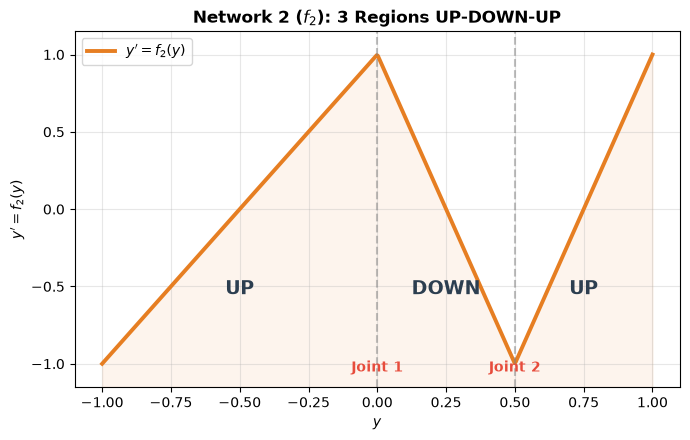

In [4]:
class ShallowNet2:
    def __init__(self):
        self.theta_0 = np.array([1.0, 0.0, -0.5])
        self.theta_1 = np.array([1.0, 1.0,  1.0])
        self.phi_0   = -1.0
        self.phi     = np.array([2.0, -6.0, 8.0])

    def forward(self, y):
        h1 = relu(self.theta_0[0] + self.theta_1[0] * y)
        h2 = relu(self.theta_0[1] + self.theta_1[1] * y)
        h3 = relu(self.theta_0[2] + self.theta_1[2] * y)
        yp = self.phi_0 + self.phi[0]*h1 + self.phi[1]*h2 + self.phi[2]*h3
        return yp, (h1, h2, h3)

net2 = ShallowNet2()
# 可视化 f2
y_dense = np.linspace(-1, 1, 500)
yp_dense, _ = net2.forward(y_dense)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(y_dense, yp_dense, '#E67E22', linewidth=2.8, label=r"$y' = f_2(y)$")
for yj in [0, 0.5]:
    ax.axvline(x=yj, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(y_dense, yp_dense, -1.15, alpha=0.08, color='#E67E22')
for yj, lbl in [(0, 'Joint 1'), (0.5, 'Joint 2')]:
    ax.text(yj, -1.05, lbl, fontsize=10, ha='center', color='#E74C3C', fontweight='bold')
for ym, d in [(-0.5, 'UP'), (0.25, 'DOWN'), (0.75, 'UP')]:
    ax.text(ym, -0.55, d, fontsize=14, ha='center', color='#2C3E50', fontweight='bold')
ax.set_xlabel('$y$'); ax.set_ylabel("$y' = f_2(y)$")
ax.set_title('Network 2 ($f_2$): 3 Regions UP-DOWN-UP', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15)
plt.tight_layout(); plt.show()

现在把两个网络串联：$y' = f_2(f_1(x))$。根据设计：

- $f_1$ 把 $x \in [-1,1]$ 分为 3 段（斜率 +3, -3, +3），每段完整遍历 $y \in [-1,1]$
- $f_2$ 把 $y \in [-1,1]$ 分为 3 段（斜率 +2, -4, +4），形成 ↑↓↑ 的折线模式
- 组合后 $f_2$ 的 ↑↓↑ 模式在 $f_1$ 的**每一个**区域都被"复印"
- **Fold 1（斜率正）**：↑↓↑ 正向保留
- **Fold 2（斜率负）**：被翻转为 ↓↑↓！
- **Fold 3（斜率正）**：↑↓↑ 再次正向保留

结果：$3 \times 3 = 9$ 个线性区域！仅用 $3+3=6$ 个隐藏单元（6 单元浅层网络最多 7 个区域）。

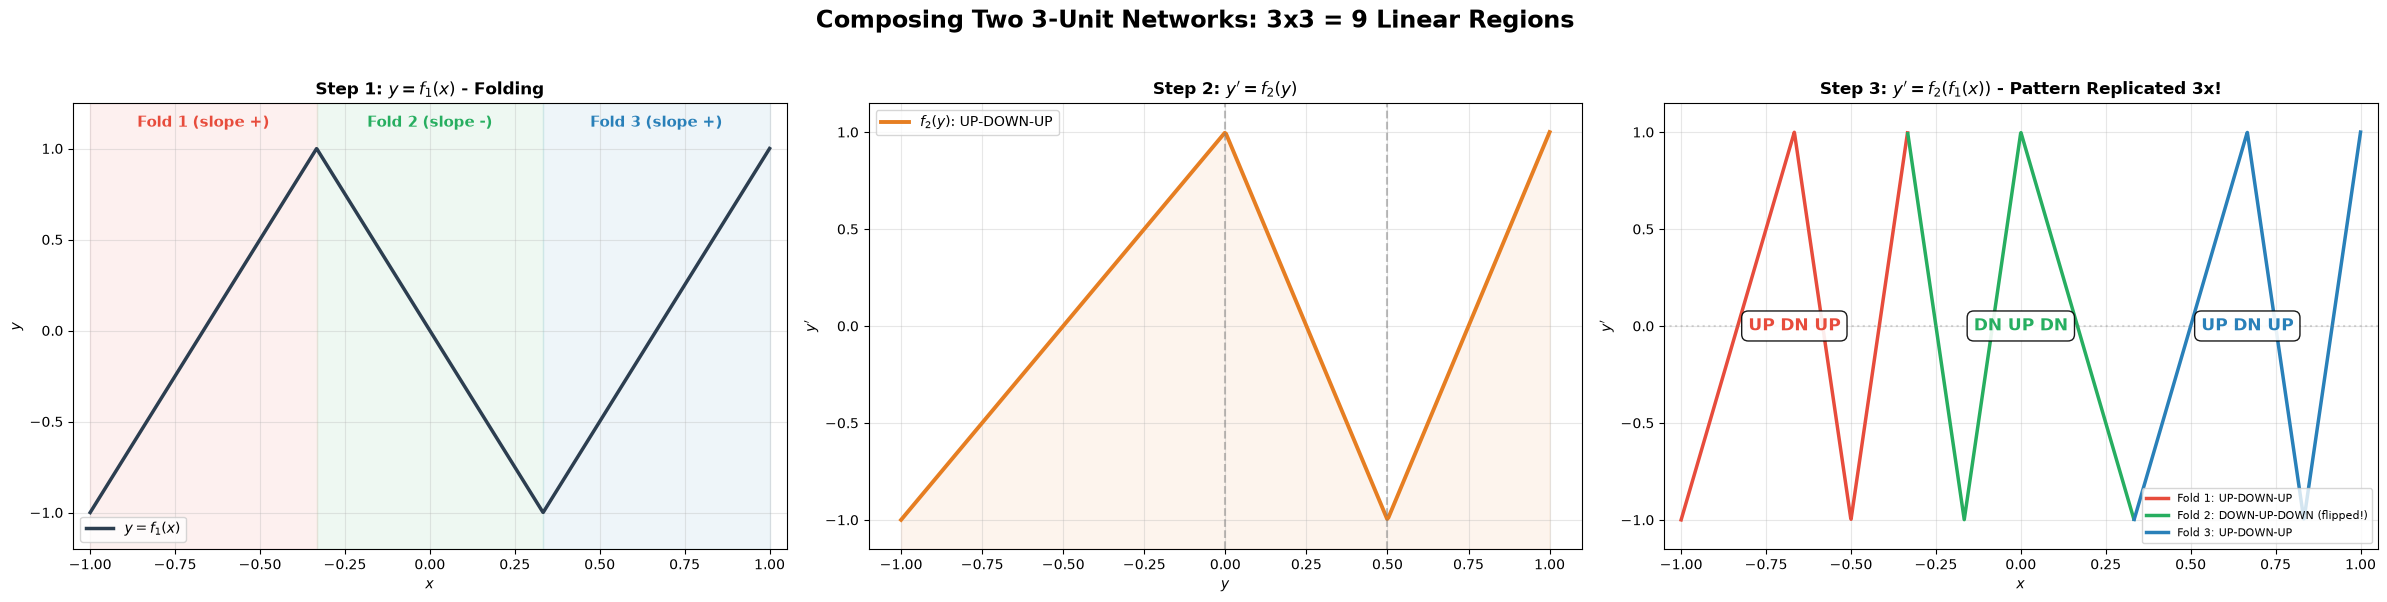

In [5]:
x_dense = np.linspace(-1, 1, 2000)
y_inter, _ = net1.forward(x_dense)
y_final, _ = net2.forward(y_inter)

fig, axes = plt.subplots(1, 3, figsize=(24, 5.8))

fold_colors = ['#E74C3C', '#27AE60', '#2980B9']
fold_bounds = [(-1, -1/3), (-1/3, 1/3), (1/3, 1)]

# Panel A: f1 output
ax = axes[0]
ax.plot(x_dense, y_inter, '#2C3E50', linewidth=2.5, label=r'$y = f_1(x)$')
for (xs,xe),c,lbl in zip(fold_bounds,fold_colors,
    ['Fold 1 (slope +)', 'Fold 2 (slope -)', 'Fold 3 (slope +)']):
    ax.axvspan(xs, xe, alpha=0.08, color=c)
    ax.text((xs+xe)/2, 1.12, lbl, fontsize=11, ha='center', fontweight='bold', color=c)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Step 1: $y = f_1(x)$ - Folding', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.2, 1.25)

# Panel B: f2 on y
ax = axes[1]
yd = np.linspace(-1, 1, 500); ypd, _ = net2.forward(yd)
ax.plot(yd, ypd, '#E67E22', linewidth=2.8, label=r"$f_2(y)$: UP-DOWN-UP")
ax.fill_between(yd, ypd, -1.15, alpha=0.08, color='#E67E22')
for yj in [0, 0.5]:
    ax.axvline(x=yj, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('$y$'); ax.set_ylabel("$y'$")
ax.set_title('Step 2: $y\' = f_2(y)$', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.15, 1.15)

# Panel C: composition
ax = axes[2]
patterns = ['Fold 1: UP-DOWN-UP', 'Fold 2: DOWN-UP-DOWN (flipped!)', 'Fold 3: UP-DOWN-UP']
arrows = ['UP DN UP', 'DN UP DN', 'UP DN UP']
for (xs,xe),c,lbl,arr in zip(fold_bounds,fold_colors,patterns,arrows):
    mask = (x_dense >= xs) & (x_dense <= xe)
    ax.plot(x_dense[mask], y_final[mask], color=c, linewidth=2.5, label=lbl)
    ax.annotate(arr, xy=((xs+xe)/2, 0), fontsize=12, ha='center', va='center',
                color=c, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$'); ax.set_ylabel("$y'$")
ax.set_title('Step 3: $y\'=f_2(f_1(x))$ - Pattern Replicated 3x!', fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.15, 1.15)

fig.suptitle('Composing Two 3-Unit Networks: 3x3 = 9 Linear Regions',
             fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


## 3.3 如何理解组合浅层网络——以复合函数的视角

在UDL书中，作者给出两个理解角度，

## 3.5 深度 vs 宽度：定量比较

### 线性区域数量

对于**单输入单输出**的 ReLU 网络（UDL 第 4.5.2 节）：

| 网络类型 | 隐藏单元使用 | 参数数量 | 最大线性区域数 |
|:---|:---|:---|:---|
| 浅层网络 | $D$ 个，同一层 | $3D+1$ | $D+1$ |
| 深度网络 | $K$ 层，每层 $D$ 个 | $3D+1+(K-1)D(D+1)$ | $(D+1)^K$ |

我们的例子（$K=2, D=3$）：组合网络理论上最多 $4^2=16$ 个区域（实际 9 个），$3+1+(1)(3)(4)=16$ 个参数；浅层 $D=6$ 最多 7 个区域，19 个参数。

**相同参数下，深度网络产生指数级更多区域！**

### 深度效率（Depth Efficiency）

存在某些函数，用浅层网络逼近需要**指数级**更多的隐藏单元。用深度网络可以"廉价"表达，用浅层网络代价极高——这正是"深度"二字的深层含义。

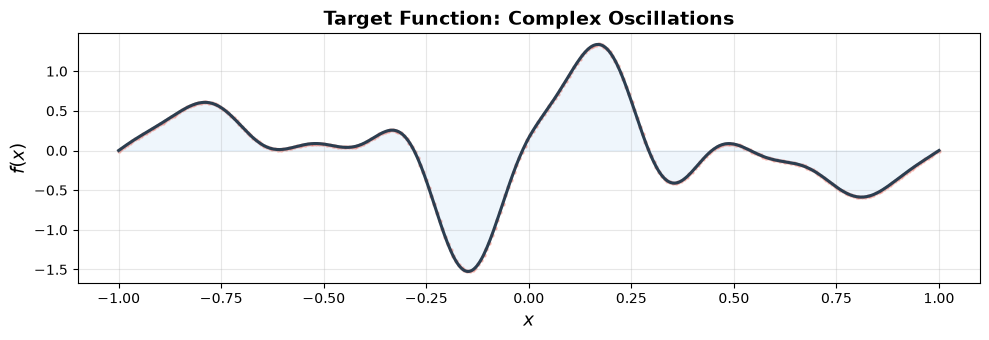

In [6]:
np.random.seed(42)

def complex_target(x):
    return (np.sin(4 * np.pi * x) * np.exp(-x**2 / 0.3) +
            0.3 * np.cos(8 * np.pi * x + 1.0) * (1 - np.abs(x)) +
            0.5 * np.sin(2 * np.pi * x))

X_train = np.linspace(-1, 1, 300).reshape(-1, 1)
y_train = complex_target(X_train).ravel()

fig, ax = plt.subplots(figsize=(10, 3.5))
X_plot = np.linspace(-1, 1, 500)
ax.plot(X_plot, complex_target(X_plot), '#2C3E50', linewidth=2.2)
ax.fill_between(X_plot, complex_target(X_plot), alpha=0.08, color='#3498DB')
ax.scatter(X_train.ravel(), y_train, s=5, alpha=0.3, c='#E74C3C')
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$f(x)$', fontsize=13)
ax.set_title('Target Function: Complex Oscillations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
class DeepNN:
    """K-layer NN with ReLU + Adam"""
    def __init__(self, layer_sizes, lr=0.005, epochs=15000):
        self.layer_sizes = layer_sizes; self.lr = lr; self.epochs = epochs
        self.loss_history = []

    def _init_params(self):
        self.W, self.b = [], []
        for i in range(len(self.layer_sizes)-1):
            di, do = self.layer_sizes[i], self.layer_sizes[i+1]
            self.W.append(np.random.randn(di, do)*np.sqrt(2.0/max(di,1)))
            self.b.append(np.zeros((1, do)))

    def _init_adam(self):
        self.mW=[np.zeros_like(w) for w in self.W]
        self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]
        self.vb=[np.zeros_like(b) for b in self.b]

    def _forward(self, X):
        layers = []; a = X
        for i in range(len(self.W)-1):
            z = a @ self.W[i] + self.b[i]; a = relu(z)
            layers.append((z, a))
        z = a @ self.W[-1] + self.b[-1]
        layers.append((z, z)); return layers

    def fit(self, X, y):
        n = X.shape[0]; y = y.reshape(-1, 1)
        self._init_params(); self._init_adam()
        b1, b2, eps = 0.9, 0.999, 1e-8
        for epoch in range(self.epochs):
            layers = self._forward(X); yp = layers[-1][1]
            loss = np.mean((yp-y)**2); self.loss_history.append(loss)
            L = len(self.W); dL = (2.0/n)*(yp-y)
            for l in reversed(range(L)):
                ap = layers[l-1][1] if l>0 else X
                dW = ap.T @ dL; db = np.sum(dL, axis=0, keepdims=True)
                dL_nxt = None
                if l > 0:
                    dA = dL @ self.W[l].T
                    dL_nxt = dA * (layers[l-1][0] > 0).astype(float)
                t = epoch+1
                for param, grad, m, v in [(self.W[l],dW,self.mW[l],self.vW[l]),
                                           (self.b[l],db,self.mb[l],self.vb[l])]:
                    m[:]=b1*m+(1-b1)*grad; v[:]=b2*v+(1-b2)*grad**2
                    param -= self.lr*(m/(1-b1**t))/(np.sqrt(v/(1-b2**t))+eps)
                if l>0: dL = dL_nxt

    def predict(self, X):
        return self._forward(X)[-1][1].ravel()

def count_params(sizes):
    return sum(sizes[i]*sizes[i+1]+sizes[i+1] for i in range(len(sizes)-1))

configs = [
    ("Shallow Wide (1 layer, 30 units)", [1, 30, 1], '#E74C3C'),
    ("Deep Narrow (4 layers, 5 each)",   [1, 5, 5, 5, 5, 1], '#2980B9'),
]

results = {}
for name, arch, color in configs:
    np.random.seed(42)
    n_p = count_params(arch)
    print(f"Training: {name} - {n_p} params")
    model = DeepNN(layer_sizes=arch, lr=0.008, epochs=20000)
    model.fit(X_train, y_train)
    results[name] = {'model': model, 'params': n_p, 'color': color}
    print(f"  Final MSE: {model.loss_history[-1]:.6f}")

print("\\nTraining complete!")

Training: Shallow Wide (1 layer, 30 units) - 91 params
  Final MSE: 0.074661
Training: Deep Narrow (4 layers, 5 each) - 106 params
  Final MSE: 0.012941
\nTraining complete!


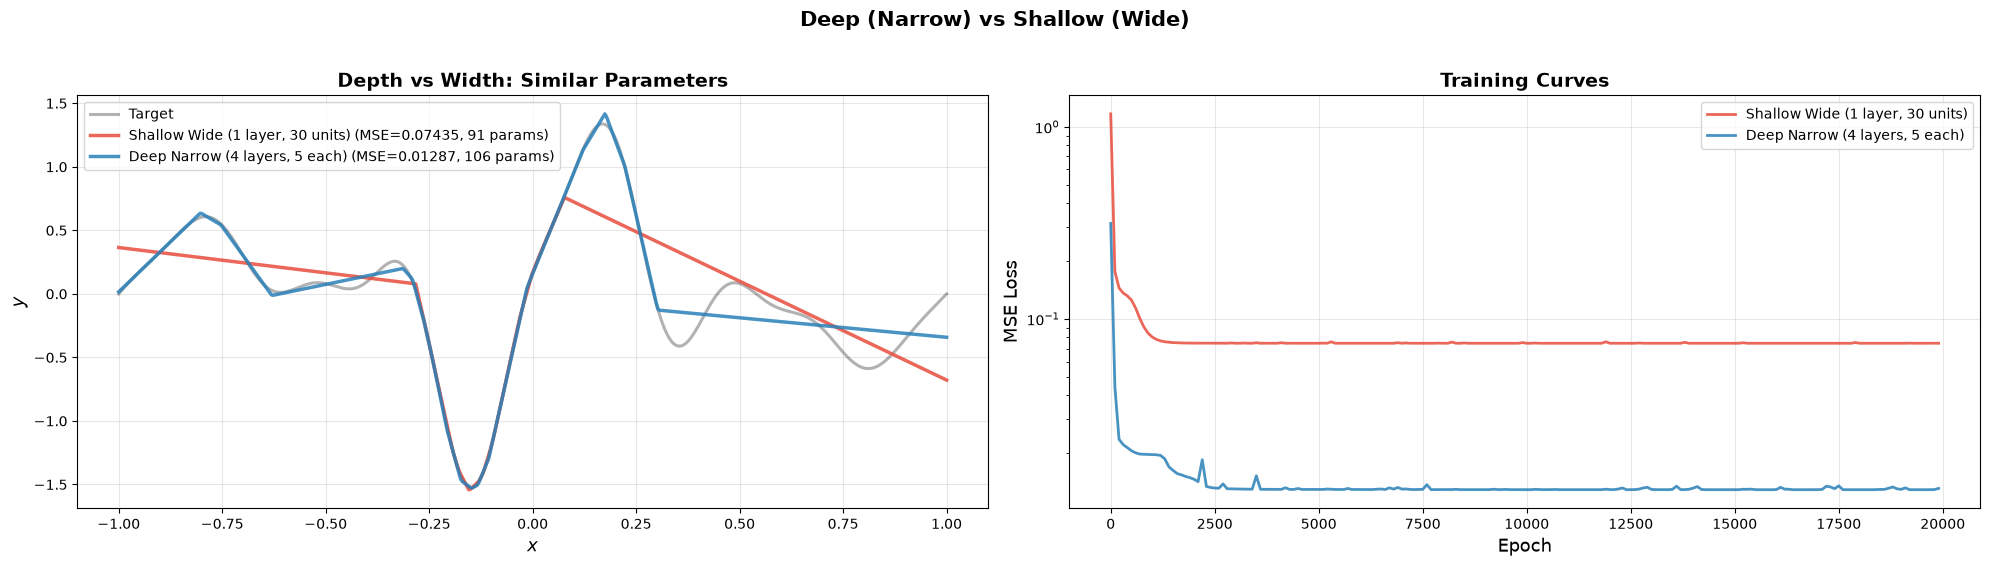

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5.5))
X_test = np.linspace(-1, 1, 500).reshape(-1, 1)
y_true = complex_target(X_test).ravel()

ax = axes[0]
ax.plot(X_test, y_true, 'k-', linewidth=2.2, alpha=0.3, label='Target')
for name, res in results.items():
    yp = res['model'].predict(X_test)
    mse = np.mean((yp-y_true)**2)
    ax.plot(X_test, yp, res['color'], linewidth=2.5, alpha=0.85,
            label=f"{name} (MSE={mse:.5f}, {res['params']} params)")
ax.set_xlabel('$x$', fontsize=13); ax.set_ylabel('$y$', fontsize=13)
ax.set_title('Depth vs Width: Similar Parameters', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
for name, res in results.items():
    losses = res['model'].loss_history
    steps = np.arange(0, len(losses), 100)
    ax.plot(steps, [losses[i] for i in steps], res['color'], linewidth=2,
            alpha=0.85, label=name)
ax.set_xlabel('Epoch', fontsize=13); ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('Training Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.set_yscale('log'); ax.grid(True, alpha=0.3)

fig.suptitle('Deep (Narrow) vs Shallow (Wide)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 3.6 小结

本章我们沿着第二章"折叠空间"的直觉，深入探讨了深度神经网络的工作机制。

### 1. 深度 = 反复折叠

每一层都在对上一层的输出空间进行"折叠"。多个不同输入被映射到同一位置，下一层的函数因此被"复印"到多个位置——正斜率区域保留、负斜率区域翻转——产生指数增长的大量线性区域。

$$
\text{一层: 折 1 次} \quad \Longrightarrow \quad K \text{ 层: 折 } K \text{ 次} \quad \Longrightarrow \quad \text{区域数 } \propto (D+1)^K
$$

### 2. 两种互补视角

- **折叠空间视角**：解释函数中的**对称性和重复模式**——为什么会有结构化的复制
- **裁剪重组视角**：解释**新关节的产生机制**——ReLU 每次应用在零线处创造新断点

### 3. 组合 ⊂ 深度网络

组合两个浅层网络等价于受约束的两层深度网络——第二层权重矩阵被约束为外积 $\Psi = \boldsymbol{\theta}'_1 \boldsymbol{\phi}^\top$（秩为 1）。真正的深度网络无此约束，拥有更大表达能力。

### 4. 深度的实际优势

- **参数效率**：相同参数量，深度网络产生指数级更多线性区域
- **深度效率**：某些函数用浅层网络需指数级更多单元才能逼近
- **层次化特征**：每层在上层基础上构建，形成从简单到复杂的特征层次

### 思考题

1. 如果 $f_1$ 的所有斜率都是正的（单调递增），还会有"复制"效应吗？为什么"折叠"需要交替的正负斜率？
2. 第一个网络有 $m$ 个区域、第二个有 $n$ 个区域，组合后最多有多少个？和 $(D+1)^K$ 公式一致吗？
3. "折叠"直觉在输入维度 $D_i > 1$ 时如何推广？（参考 UDL 图 4.2 的二维例子）

---

在下一章中，我们将进入**反向传播**（Backpropagation）——深度网络如何通过链式法则高效计算梯度，从而学习最优的折叠方式。